In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import os
from scipy.stats import kendalltau
from scipy import stats
import numpy as np
import cartopy.crs as ccrs
import cartopy
import geopandas as gpd


In [2]:
# Store site metadata (site number, site name, catchment number, NZTME, NZTMN)
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)
'''
# load flow data into dataframe
flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/full_records.csv')
flow_df.date = pd.to_datetime(flow_df.date)
flow_df.set_index('date', inplace=True)
flow_df = flow_df['1969':'2019']
'''
flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/new_full_records.csv')
flow_df.date = pd.to_datetime(flow_df.date)
flow_df.set_index('date', inplace=True)
flow_df = flow_df['1969':'2019']


# define alpha and numeric season order
seasons_a = ['Winter','Spring','Summer','Autumn']
seasons_n = [6,9,12,3]

In [3]:

fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")

catchments_df = catchment_data.loc[catchment_data['SITE'].isin(flow_df.columns)]

subset_meta = metadata_df.loc[[int(s) for s in flow_df.columns]]

subset_meta.sort_values('gauge_lat', ascending = False, inplace=True)
subset_meta['number_label'] = np.arange(1,len(subset_meta)+1)
subset_meta['number_copy'] = subset_meta.index.values.tolist()

meta_df = gpd.GeoDataFrame(subset_meta, 
                           geometry=gpd.points_from_xy(x=subset_meta.gauge_lon, y=subset_meta.gauge_lat),
                           crs='EPSG:4326')

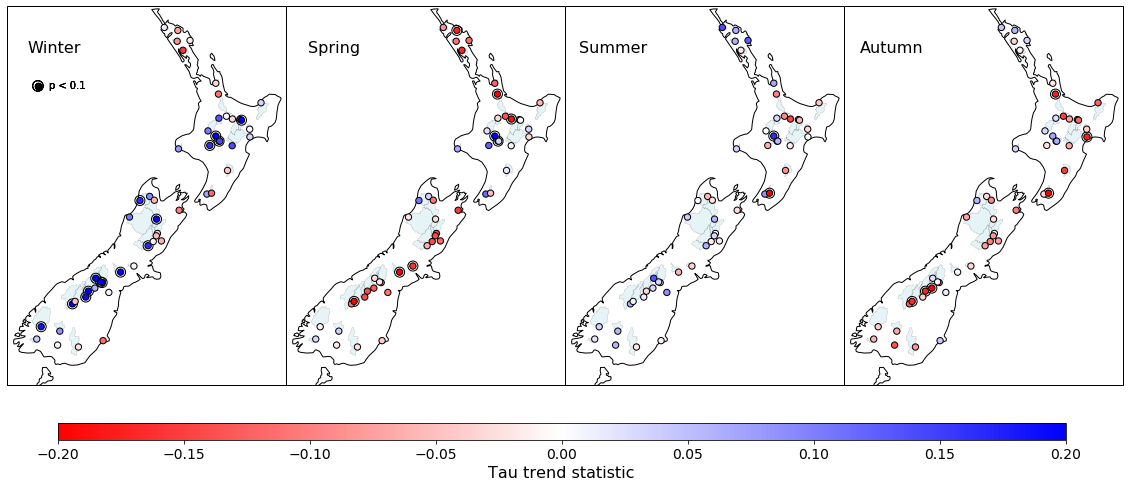

In [4]:
# Define the CartoPy CRS object.
crs = ccrs.Mercator()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
catchments_df_ae = catchments_df.to_crs(crs_proj4)
meta_df_ae = meta_df.to_crs(crs_proj4)

fig, axs = plt.subplots(1,4, subplot_kw={'projection': crs},figsize=(20,12))
axs = axs.flatten()

for i,season in enumerate(seasons_n):
    #print()
    #print(season)
    
    axs[i].coastlines(resolution='50m', color='black',linewidth=1,zorder = 1)
    axs[i].set_xlim([18500000,19900000])
    axs[i].set_ylim([-5950000,-4050000])
    axs[i].text(.17, .89, seasons_a[i], fontsize= 16, horizontalalignment="center", verticalalignment="center", transform=axs[i].transAxes)

    catchments_df_ae.plot(ax=axs[i],color='lightblue',edgecolor='black',linewidth=0.2,alpha=0.3)
    
    df_season = flow_df[flow_df.index.month.isin([season])]

    lats = []
    lons = []
    taus = []
    ps = []
    for site in df_season:
        years = df_season[site].index.year.values
        time_series = df_season[site].values
        
        lon = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][0]
        lat = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][1]
        
        coef, p = kendalltau(years, time_series, nan_policy='omit')
        
        if p < 0.1:
            axs[i].scatter(lon,lat, marker='o',facecolors='none', edgecolors='black',s=100,zorder=10)
        
        lats.append(lat)
        lons.append(lon)
        taus.append(coef)
        ps.append(p)
        
        #print(site + ': ' + str(coef) + " " + str(p))

    im = axs[i].scatter(lons,lats,c=taus, cmap='bwr_r',marker='o',alpha=1,s=40,vmin=-.2,vmax=0.2,edgecolor='black',zorder=100)

    axs[0].scatter(.11, .79, marker='o',facecolors='black', edgecolors='black',s=40, transform=axs[0].transAxes)
    axs[0].scatter(.11, .79, marker='o',facecolors='none', edgecolors='black',s=110, transform=axs[0].transAxes)
    axs[0].text(.15, .785, 'p < 0.1', transform=axs[0].transAxes)


plt.subplots_adjust(wspace=0, hspace=0)

cax = fig.add_axes([0.16,0.22,.7,.02])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Tau trend statistic',size=16)

#plt.savefig('Figure3.png',dpi=300,bbox_inches='tight')
